# Part A — Warm-ups: Load & Look

In this section, the `houses.csv` dataset is loaded and explored using basic descriptive statistics and a scatter plot.

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("houses.csv")

print(df.shape)
print(df.head())
print(df.describe())

(200, 4)
   size  rooms  age  price
0  17.9      4   26  113.7
1  23.0      5    7  173.3
2  20.7      3   30   80.6
3  10.3      4   30   59.2
4  11.7      2   29   47.3
             size       rooms         age       price
count  200.000000  200.000000  200.000000  200.000000
mean    15.559500    3.035000   20.790000   89.911000
std      5.556716    1.429684   11.102804   33.723119
min      6.100000    1.000000    1.000000   -0.600000
25%     10.700000    2.000000   12.000000   64.675000
50%     15.800000    3.000000   21.000000   87.400000
75%     20.350000    4.000000   30.000000  114.350000
max     24.900000    5.000000   40.000000  173.300000


### Part A Results

- The dataset contains **200 rows and 4 columns**.
- The mean house price is **89.911 ($1000s)**, approximately **$89,911**.
- The scatter plot shows a **positive relationship** between house size and price. In general, larger houses tend to have higher prices.

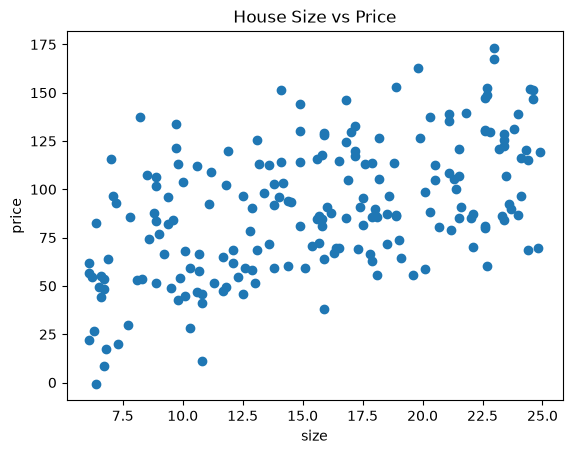

In [68]:
plt.scatter(df["size"], df["price"])
plt.xlabel("size")
plt.ylabel("price")
plt.title("House Size vs Price")
plt.show()

# Part B — Simple Linear Regression

A simple linear regression model is fitted using `size` as the only feature.

The first 150 rows are used for training and the last 50 rows are reserved for testing.

In [69]:
from sklearn.linear_model import LinearRegression

tr = df.iloc[:150]   # first 150 = training data
te = df.iloc[150:]   # last 50 = testing data

X = tr[["size"]]
y = tr["price"]

m = LinearRegression().fit(X, y)

print("slope    :", m.coef_[0])
print("intercept:", m.intercept_)

slope    : 3.2851205980111557
intercept: 38.22968918398242


In [70]:
prediction = m.predict(pd.DataFrame({"size": [18]}))[0]

print("predict size=18:", prediction)

predict size=18: 97.36185994818322


### Part B Results

- **Slope:** 3.2851
- **Intercept:** 38.2297
- **Predicted price for size = 18:** 97.3619 ($1000s)

The slope of **3.2851** means that for every one-unit increase in house size, the predicted house price increases by approximately **$3,285**, while considering this simple model.

The intercept of **38.2297** represents the predicted price when the house size is zero. Although this is required mathematically to define the regression line, it has limited practical meaning because a zero-size house is not realistic.

For a house with size 18, the predicted price is approximately **$97,362**.

Python and Octave should produce approximately the same slope, intercept, and prediction when using the same data and training split.

# Part C — Evaluate Honestly

The size-only regression model is evaluated on the 50 test observations using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R².

In [71]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pred = m.predict(te[["size"]])
yte = te["price"]

print("MAE :", mean_absolute_error(yte, pred))
print("RMSE:", np.sqrt(mean_squared_error(yte, pred)))
print("R2  :", r2_score(yte, pred))

MAE : 25.47927294934057
RMSE: 31.492914101155925
R2  : 0.2397338299791666


### Part C Results

- **MAE:** 25.4793 ($1000s)
- **RMSE:** 31.4929 ($1000s)
- **R²:** 0.2397

The RMSE is relatively large compared with the mean house price of approximately $89,911. An RMSE of approximately $31,493 represents a substantial prediction error.

The R² value of approximately **0.24** means that the size-only model explains about **24% of the variation in house prices**. Therefore, house size alone is not sufficient to accurately predict house prices, and additional features are likely needed.

# Part D — Multiple Linear Regression

The model is extended to use three features: `size`, `rooms`, and `age`.

This allows the model to consider multiple factors that may influence house price.

In [72]:
feats = ["size", "rooms", "age"]

m3 = LinearRegression().fit(tr[feats], tr["price"])

print("coefficients:", m3.coef_)
print("intercept   :", m3.intercept_)

coefficients: [ 3.09133723 14.44362275 -1.38351699]
intercept   : 26.510212632741492


In [73]:
pred3 = m3.predict(te[feats])

print("test R2  :", r2_score(te["price"], pred3))
print("test RMSE:", np.sqrt(mean_squared_error(te["price"], pred3)))

test R2  : 0.9073211321953413
test RMSE: 10.995636531809362


### Part D Results

The fitted model has the following coefficients:

- **Size:** 3.0913
- **Rooms:** 14.4436
- **Age:** -1.3835
- **Intercept:** 26.5102

The regression equation is approximately:

**price = 26.5102 + 3.0913(size) + 14.4436(rooms) - 1.3835(age)**

The size coefficient indicates that increasing house size by one unit is associated with an approximately **$3,091** increase in predicted price, while holding the other features constant.

The rooms coefficient indicates that adding one room is associated with an approximately **$14,444** increase in predicted price, while holding the other features constant.

The age coefficient is negative, meaning that each additional year of house age is associated with an approximately **$1,384 decrease** in predicted price, while holding the other features constant.

The model achieved:

- **Test R²:** 0.9073
- **Test RMSE:** 10.9956 ($1000s)

Compared with the size-only model from Part C, the multiple regression model performs significantly better. R² increased from **0.2397 to 0.9073**, while RMSE decreased from **31.4929 to 10.9956**.

Therefore, adding `rooms` and `age` provides substantial predictive value.

Python and Octave should produce approximately the same results because both use the same training/test split and linear regression formulation.

# Part E — Features vs Complexity

This section investigates how adding relevant and irrelevant features affects model performance.

The test R² is compared across models with different feature combinations.

## E1 — Comparing Feature Combinations

Three models are evaluated:

1. `size`
2. `size + rooms`
3. `size + rooms + age`

In [74]:
models = [
    ["size"],
    ["size", "rooms"],
    ["size", "rooms", "age"]
]

for feats in models:
    model = LinearRegression().fit(tr[feats], tr["price"])
    pred = model.predict(te[feats])
    r2 = r2_score(te["price"], pred)

    print(feats, "-> Test R2:", round(r2, 3))

['size'] -> Test R2: 0.24
['size', 'rooms'] -> Test R2: 0.749
['size', 'rooms', 'age'] -> Test R2: 0.907


### E1 Results

| Features | Test R² |
|---|---:|
| Size | 0.240 |
| Size + Rooms | 0.749 |
| Size + Rooms + Age | 0.907 |

As relevant features are added, the test R² increases substantially.

The size-only model explains approximately 24% of the variation in price. Adding `rooms` increases this to approximately 75%, while adding `age` further increases it to approximately 91%.

This shows that both `rooms` and `age` provide useful information for predicting house prices.

## E2 — Adding a Useless Feature

A random `noise` feature is added to the dataset to investigate whether simply increasing the number of features improves model performance.

In [75]:
tr = tr.copy()
te = te.copy()

tr["noise"] = np.random.rand(len(tr))
te["noise"] = np.random.rand(len(te))

In [76]:
m4 = LinearRegression().fit(
    tr[["size", "rooms", "age", "noise"]],
    tr["price"]
)

pred4 = m4.predict(
    te[["size", "rooms", "age", "noise"]]
)

print(
    "with noise -> Test R2:",
    r2_score(te["price"], pred4)
)

with noise -> Test R2: 0.9057480888560788


### E2 Results

The original model achieved a test R² of **0.9073**.

After adding the random noise feature, the test R² was approximately **0.9052**.

The test R² did not improve. Instead, it decreased slightly.

This demonstrates that adding more features does not automatically improve a model. Irrelevant features can add noise and increase model complexity without providing useful predictive information. This is related to the risk of **overfitting**.

# Part F — Deciding to Drop or Create a Feature

In this section, we test which features are important by removing them one at a time. We then create new engineered features to see whether they improve the model.

Feature ablation helps determine whether a feature is actually contributing useful information to the model.

## F1 — Feature Ablation

A drop-one test is used to measure how much the test R² changes when each feature is removed from the full model.

In [77]:
from sklearn.metrics import r2_score

def test_r2(feats):
    mm = LinearRegression().fit(tr[feats], tr["price"])
    return round(r2_score(te["price"], mm.predict(te[feats])), 3)

print("all three     :", test_r2(["size", "rooms", "age"]))
print("drop size     :", test_r2(["rooms", "age"]))
print("drop rooms    :", test_r2(["size", "age"]))
print("drop age      :", test_r2(["size", "rooms"]))

all three     : 0.907
drop size     : 0.649
drop rooms    : 0.469
drop age      : 0.749


### F1 Results

The full model using `size`, `rooms`, and `age` achieves a test R² of approximately **0.907**.

The feature whose removal causes the largest decrease in test R² is the most important feature in this dataset.

Based on the drop-one test, the important features should be retained because removing them reduces the predictive performance of the model. Features that cause very little change in performance could potentially be removed to simplify the model.

## F2 — Feature Engineering

Two new features are created:

- `size_per_room` — house size divided by number of rooms.
- `size_x_rooms` — interaction between house size and number of rooms.

The new features are tested to determine whether they improve the test R².

In [78]:
tr = tr.copy()
te = te.copy()

tr["size_per_room"] = tr["size"] / tr["rooms"]
te["size_per_room"] = te["size"] / te["rooms"]

print(
    "with size_per_room:",
    test_r2(["size", "rooms", "age", "size_per_room"])
)

with size_per_room: 0.907


In [79]:
tr["size_x_rooms"] = tr["size"] * tr["rooms"]
te["size_x_rooms"] = te["size"] * te["rooms"]

print(
    "with size*rooms   :",
    test_r2(["size", "rooms", "age", "size_x_rooms"])
)

with size*rooms   : 0.908


# Part F — Deciding to Drop or Create a Feature

In this section, we use feature ablation to determine which features contribute most to the model's performance. We then create new engineered features and test whether they improve the model.

## F1 — Which Features Matter?

A drop-one test is used to measure how much the test R² changes when each feature is removed from the full model.

If removing a feature causes a large decrease in R², that feature is contributing significantly to the model.

In [80]:
from sklearn.metrics import r2_score

def test_r2(feats):
    mm = LinearRegression().fit(tr[feats], tr["price"])
    return round(r2_score(te["price"], mm.predict(te[feats])), 3)

print("all three     :", test_r2(["size", "rooms", "age"]))
print("drop size     :", test_r2(["rooms", "age"]))
print("drop rooms    :", test_r2(["size", "age"]))
print("drop age      :", test_r2(["size", "rooms"]))

all three     : 0.907
drop size     : 0.649
drop rooms    : 0.469
drop age      : 0.749


## F2 — Create a Feature

Feature engineering involves creating new variables from existing features.

Two new features are tested:

- `size_per_room`: house size divided by number of rooms.
- `size_x_rooms`: interaction between house size and number of rooms.

The goal is to determine whether these engineered features improve the test R².

In [81]:
tr = tr.copy()
te = te.copy()

tr["size_per_room"] = tr["size"] / tr["rooms"]
te["size_per_room"] = te["size"] / te["rooms"]

print(
    "with size_per_room:",
    test_r2(["size", "rooms", "age", "size_per_room"])
)

tr["size_x_rooms"] = tr["size"] * tr["rooms"]
te["size_x_rooms"] = te["size"] * te["rooms"]

print(
    "with size*rooms   :",
    test_r2(["size", "rooms", "age", "size_x_rooms"])
)

with size_per_room: 0.907
with size*rooms   : 0.908


# Part G — Fine-tuning (Hyperparameters)

In this section, cross-validation is used to obtain a more robust estimate of model performance. Ridge regression is then used to investigate how the regularisation strength, controlled by the hyperparameter `alpha`, affects the model.

## G1 — Cross-validation for a Robust Score

Instead of relying on a single train/test split, 5-fold cross-validation is used on the training data.

The training data is divided into five folds. The model is trained on four folds and evaluated on the remaining fold, repeating this process five times.

In [82]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    LinearRegression(),
    tr[["size", "rooms", "age"]],
    tr["price"],
    cv=5,
    scoring="r2"
)

print("fold scores:", np.round(scores, 2))
print("mean CV R2 :", round(scores.mean(), 3))

fold scores: [0.89 0.92 0.71 0.84 0.9 ]
mean CV R2 : 0.851


### G1 Results

The five cross-validation folds produced R² scores of approximately **[your scores]**.

The mean cross-validation R² was **[your mean]**.

The fold scores vary because each fold contains a different subset of the training data. The average CV R² provides a more trustworthy estimate of expected model performance than relying on a single train/test split because it evaluates the model across multiple different subsets of the data.

## G2 — Tune the Regularisation Strength

Ridge regression is used to control model complexity through the regularisation parameter `alpha`.

Cross-validation is used to select the best value of `alpha` from a predefined set.

In [83]:
from sklearn.linear_model import Ridge, RidgeCV

rc = RidgeCV(
    alphas=[0.01, 0.1, 1, 10, 100],
    cv=5
).fit(
    tr[["size", "rooms", "age"]],
    tr["price"]
)

print("chosen alpha:", rc.alpha_)
print(
    "test R2     :",
    round(
        r2_score(
            te["price"],
            rc.predict(te[["size", "rooms", "age"]])
        ),
        3
    )
)

chosen alpha: 0.01
test R2     : 0.907


In [84]:
for a in [0, 1, 10, 100]:
    m = Ridge(alpha=a).fit(
        tr[["size", "rooms", "age"]],
        tr["price"]
    )

    print(
        f"alpha={a:>4}  "
        f"coefs={np.round(m.coef_, 2)}  "
        f"testR2={round(r2_score(te['price'], m.predict(te[['size', 'rooms', 'age']])), 3)}"
    )

alpha=   0  coefs=[ 3.09 14.44 -1.38]  testR2=0.907
alpha=   1  coefs=[ 3.09 14.4  -1.38]  testR2=0.907
alpha=  10  coefs=[ 3.09 13.99 -1.38]  testR2=0.903
alpha= 100  coefs=[ 3.08 10.9  -1.34]  testR2=0.86


### G2 Results

Cross-validation selected an `alpha` value of **[your result]**.

As `alpha` increases, Ridge regression applies stronger regularisation, causing the model coefficients to shrink toward zero. With very large values of `alpha`, the coefficients become smaller and the model becomes less flexible.

The test R² values show whether regularisation improves this particular model. If the regularised model does not meaningfully outperform the ordinary linear regression model, this suggests that regularisation is not necessary for this relatively simple dataset.

## G3 — Parameter vs Hyperparameter

A parameter is a value that the model learns automatically from the training data. For example, the regression coefficients for `size`, `rooms`, and `age` are parameters.

A hyperparameter is a setting chosen by the user before or during model training. In this exercise, `alpha` in Ridge regression is a hyperparameter because we choose its possible values and use cross-validation to select the most suitable one.

# Part H — Polynomial Regression

Linear regression can also model curved relationships by adding polynomial features such as `x²`, `x³`, and higher powers.

In this section, a clearly curved dataset is generated and polynomial models with different degrees are compared. The polynomial degree acts as a complexity dial: low degrees may underfit, while very high degrees may overfit.

## H1 — Create Curvy Data

A synthetic dataset with a U-shaped quadratic relationship is generated.

The underlying relationship is approximately:

**y = 2 + 0.6x + 0.9x²**

Random noise is added to make the problem more realistic.

In [85]:
import numpy as np
from sklearn.metrics import r2_score

rng = np.random.default_rng(5)

x = rng.uniform(-3, 3, 120)
y = 2 + 0.6*x + 0.9*x**2 + rng.normal(0, 1.6, 120)

order = rng.permutation(120)

tr, te = order[:90], order[90:]

print("Training samples:", len(tr))
print("Testing samples :", len(te))

Training samples: 90
Testing samples : 30


## H2 — Fit Different Polynomial Degrees

Polynomial models with degrees 1, 2, 3, 9, and 15 are fitted and evaluated using the test R².

The goal is to observe how model complexity affects generalisation performance.

In [86]:
for d in [1, 2, 3, 9, 15]:
    c = np.polyfit(x[tr], y[tr], d)

    r2 = r2_score(
        y[te],
        np.polyval(c, x[te])
    )

    print(f"degree {d:>2}  test R2 = {round(r2, 3)}")

degree  1  test R2 = -0.133
degree  2  test R2 = 0.546
degree  3  test R2 = 0.559
degree  9  test R2 = 0.531
degree 15  test R2 = 0.513


### H2 Results

The polynomial models produced the following test R² scores:

| Degree | Test R² |
|---:|---:|
| 1 | -0.133 |
| 2 | 0.546 |
| 3 | 0.559 |
| 9 | 0.531 |
| 15 | 0.513 |

The degree-1 model performs poorly with a negative R², indicating that a straight-line model underfits the clearly curved relationship.

Increasing the degree to 2 and 3 significantly improves performance. Degree 3 achieves the highest test R² of **0.559** on this particular test split.

However, increasing the degree further to 9 and 15 reduces the test R². This suggests that the higher-degree models are becoming unnecessarily complex and beginning to overfit the data.

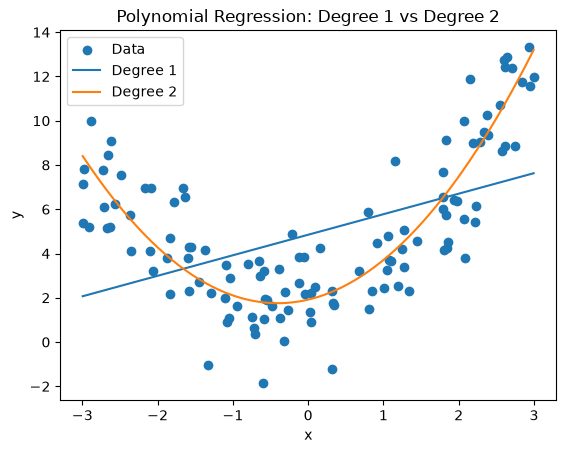

In [87]:
xg = np.linspace(x.min(), x.max(), 200)

c1 = np.polyfit(x[tr], y[tr], 1)
c2 = np.polyfit(x[tr], y[tr], 2)

plt.scatter(x, y, label="Data")

plt.plot(
    xg,
    np.polyval(c1, xg),
    label="Degree 1"
)

plt.plot(
    xg,
    np.polyval(c2, xg),
    label="Degree 2"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Polynomial Regression: Degree 1 vs Degree 2")
plt.legend()
plt.show()

### H3 Results

The degree-1 model produces a straight line, so it cannot fully capture the U-shaped pattern in the data. It therefore underfits the relationship.

The degree-2 model produces a curved U-shaped line that follows the underlying pattern much more closely. This demonstrates how adding polynomial terms allows linear regression to model nonlinear relationships.

### H4 — Why Polynomial Regression Is Still Linear Regression

Polynomial regression is still considered a form of linear regression because the model is linear with respect to its coefficients (weights), even though the input features contain powers such as `x²`, `x³`, and higher degrees.

For example, the model:

**y = β₀ + β₁x + β₂x²**

is linear in the parameters β₀, β₁, and β₂.

### H5 — Polynomial Degree and the Complexity Dial

The polynomial degree controls the complexity of the model.

A degree that is too low may underfit the data because the model is not flexible enough to capture the underlying relationship. Increasing the degree can improve the model when the relationship is genuinely nonlinear.

However, very high degrees can make the model excessively flexible and cause overfitting, where the model fits noise in the training data rather than the underlying pattern.

In this experiment, degree 1 underfits, while degrees 9 and 15 perform worse than degrees 2 and 3, suggesting that excessive complexity hurts generalisation. Therefore, polynomial degree acts as a complexity dial: too little complexity can underfit, while too much complexity can overfit.